In [15]:
import numpy as np
import matplotlib.pyplot as plt

def HH_1D(tau, m, h, n, v, nxnodes):

    Cm = 1
    g_Na = 120
    g_K = 36
    g_L = 0.3
    V_Na = 115
    V_K = -12
    V_L = 10.6
    sigma=  0.001

    bb = np.zeros(nxnodes)
    I = np.zeros((nxnodes, 3))

    for i in range(nxnodes):
    
        V = v[i]    # valore sui nodi
        M = m[i]
        H = h[i]
        N = n[i]

        am = 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1)   # update variables 
        ah = 0.07 * np.exp(-V / 20)
        an = 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1)
        bm = 4 * np.exp(-V / 18)
        bh = 1 / (np.exp((30 - V) / 10) + 1)
        bn = 0.125 * np.exp(-V / 80)

        M = (1 / tau * M + am) / (1 / tau + am + bm)    # ricalcolo variabili gating 
        H = (1 / tau * H + ah) / (1 / tau + ah + bh)
        N = (1 / tau * N + an) / (1 / tau + an + bn)

        I_Na = g_Na * M**3 * H * (V - V_Na)     # actual currents
        I_K = g_K * N**4 * (V - V_K)
        I_ion = I_Na + I_K + g_L * (V - V_L)
        f = -1 / Cm * I_ion

        m[i] = M
        h[i] = H
        n[i] = N
        bb[i] = f

        I[i, 0] = I_Na
        I[i, 1] = I_K
        I[i, 2] = I_ion

    return m, h, n, bb, I



def HH_1D_finite_differences():

    # Domain boundaries for space and time
    x0, xmax = 0, 1
    t0, tmax = 0, 50
    sigma=  0.001
    Cm = 1

    N = 100
    L = 1000

    # Discretization parameters
    h = 0.01
    tau = 0.05

    # Spatial and temporal nodes
    xnodes = np.linspace(x0, xmax, N + 1)
    tnodes = np.linspace(t0, tmax, L + 1)

    # Assemble matrices
    A = 2 * np.diag(np.ones(N + 1)) - np.diag(np.ones(N), 1) - np.diag(np.ones(N), -1)
    A[0, 0] = 1
    A[-1, -1] = 1
    A = A / h**2

    M = np.eye(N + 1)
    M[0, 0] = 0.5
    M[-1, -1] = 0.5

    A = sigma * A + M / tau

    # Initial conditions
    y0 = [2.7570e-4, 5.2934e-2, 5.9611e-1, 3.1768e-1]

    U = y0[0] * np.ones(N + 1)
    m = y0[1] * np.ones(N + 1)
    h = y0[2] * np.ones(N + 1)
    n = y0[3] * np.ones(N + 1)

    Iap = 100
    Iapp = np.zeros(N + 1)

    for i in range(N + 1):
        if xnodes[i] <= 0.04:
            Iapp[i] = Iap

    bb = np.zeros(N + 1)
    I = np.zeros((N + 1, 3))
    uu = np.zeros(N + 1)

    aux = 1
    time = 0

    xfissato = np.zeros((L + 1, 4))
    k = 0

    while t0 <= tmax:
        t0 += tau

        m, h, n, bb, I = HH_1D(tau, m, h, n, U, N + 1)

        if t0 <= 1:
            bb += Iapp / Cm

        bb = M @ bb
        bb += (1 / (tau * Cm)) * (M @ uu)

        U = np.linalg.solve(A, bb)

        uu = U

        xfissato[k, 0] = uu[51]
        xfissato[k, 1] = m[51]
        xfissato[k, 2] = h[51]
        xfissato[k, 3] = n[51]

        k += 1

        if uu[-1] > 105 and aux == 1:
            time = t0
            aux = 0

        # Plot results
        import matplotlib.pyplot as plt

        plt.subplot(4, 1, 1)
        plt.plot(tnodes, xfissato[:, 0], 'c')
        plt.legend(['Potential'])

        plt.subplot(4, 1, 2)
        plt.plot(tnodes, xfissato[:, 1], 'r')
        plt.legend(['m'])

        plt.subplot(4, 1, 3)
        plt.plot(tnodes, xfissato[:, 2], 'b')
        plt.legend(['h'])

        plt.subplot(4, 1, 4)
        plt.plot(tnodes, xfissato[:, 3], 'g')
        plt.legend(['n'])

        plt.show()

        # Propagation speed
        v = 1 / (time + 0.00000001)


        return v

    # Example usage
    # v = HH_1D_finite_differences()
    # print("Propagation speed:", v)


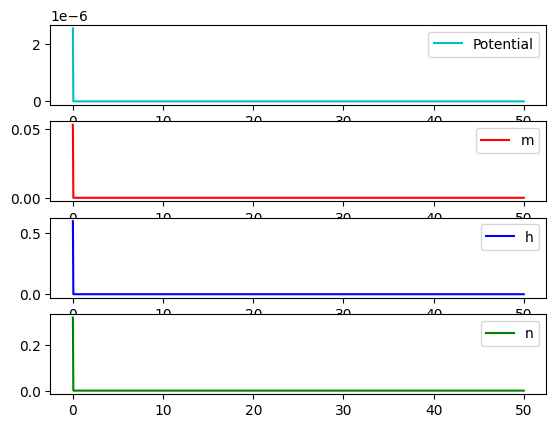

100000000.0

In [16]:
HH_1D_finite_differences()